# CHATBOT LUẬT VIỆT NAM DỰA TRÊN KIẾN TRÚC RAG (RETRIEVAL-AUGMENTED GENERATION)

## 1. Giới thiệu
Trong những năm gần đây, các mô hình ngôn ngữ lớn (Large Language Models – LLMs) cho thấy khả năng sinh văn bản tự nhiên rất mạnh mẽ. Tuy nhiên, các mô hình này thường gặp hạn chế trong việc trả lời chính xác các câu hỏi liên quan đến tri thức chuyên ngành, đặc biệt là lĩnh vực pháp luật, do dữ liệu huấn luyện không được cập nhật đầy đủ hoặc không mang tính chuyên biệt.

Để khắc phục hạn chế trên, bài toán này xây dựng **Chatbot Luật Việt Nam** dựa trên kiến trúc **Retrieval-Augmented Generation (RAG)**. Thay vì chỉ dựa vào tri thức nội tại của mô hình sinh văn bản, hệ thống kết hợp thêm cơ chế truy hồi các văn bản pháp luật liên quan từ một kho tri thức bên ngoài, từ đó nâng cao độ chính xác và giảm hiện tượng sinh thông tin sai (“hallucination”).

---

## 2. Nguồn dữ liệu
Dữ liệu pháp luật được sử dụng trong dự án được tải từ **Kaggle** với tên **Vietnamese Legal Dataset** do người dùng *quangbut* cung cấp:

🔗 **https://www.kaggle.com/datasets/quangbut/vietnamese-legal**

Tập dữ liệu này gồm các văn bản pháp luật tiếng Việt đã được thu thập và xử lý, trong đó:
- `sent_truncated_vbpl_legal_only.csv`: corpus các đoạn văn bản luật đã được tách và rút gọn.
- `dvc.json`, `dvc_test.json`: các tập câu hỏi / ví dụ dùng để kiểm thử hệ thống.

Dữ liệu này sẽ là **nguồn tri thức chính** để hệ thống RAG truy hồi và cung cấp ngữ cảnh cho việc sinh câu trả lời.

---

## 3. Mục tiêu của bài toán
Mục tiêu của bài này là:
- Xây dựng một chatbot hỗ trợ trả lời câu hỏi về **pháp luật Việt Nam**.
- Áp dụng kiến trúc **RAG** để kết hợp giữa truy hồi tri thức và sinh câu trả lời.
- Đánh giá hiệu quả truy hồi thông qua độ trễ (latency) và lựa chọn tham số top-k phù hợp.
- Minh hoạ khả năng sinh câu trả lời của mô hình Transformer dựa trên ngữ cảnh pháp luật truy hồi được.

---

## 4. Kiến trúc tổng quát của hệ thống
Hệ thống được xây dựng theo các bước chính sau:
1. **Tiền xử lý dữ liệu**: Nạp và làm sạch tập văn bản luật Việt Nam, xây dựng metadata và thông tin trích dẫn.
2. **Chia đoạn (Chunking)**: Mỗi đoạn luật được xem là một đơn vị tri thức độc lập (chunk) với độ dài phù hợp.
3. **Embedding & Indexing**: Sử dụng mô hình Transformer để mã hoá các đoạn luật và xây dựng chỉ mục FAISS cho truy hồi nhanh.
4. **Retrieval**: Truy hồi top-k đoạn luật liên quan nhất với câu hỏi của người dùng.
5. **Generation**: Kết hợp các đoạn luật truy hồi được với mô hình Transformer sinh văn bản để tạo câu trả lời.
6. **Đánh giá & phân tích**: Phân tích thống kê dữ liệu, đo độ trễ truy hồi và đánh giá lựa chọn tham số.

---

## 5. Phạm vi và giới hạn
- Hệ thống **không huấn luyện lại mô hình ngôn ngữ**, mà sử dụng các mô hình Transformer đã được huấn luyện sẵn.
- Trọng tâm của bài là **tích hợp và triển khai kiến trúc RAG**, không tập trung vào fine-tuning mô hình.
- Chatbot hỗ trợ trả lời dựa trên nội dung pháp luật trong tập dữ liệu được cung cấp, không thay thế tư vấn pháp lý chính thức.

---

## 6. Ý nghĩa của bài toán
Bài toán minh hoạ cách áp dụng kiến trúc RAG trong một lĩnh vực chuyên ngành cụ thể là pháp luật Việt Nam. Kết quả cho thấy việc kết hợp truy hồi tri thức và mô hình sinh văn bản giúp cải thiện độ chính xác, tăng tính giải thích và phù hợp cho các hệ thống hỏi–đáp chuyên ngành trong thực tế.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# giải nén
!mkdir -p /content/laws
!unzip -o "/content/drive/MyDrive/Datasets/laws.zip" -d /content/laws
!ls -lah /content/laws

Archive:  /content/drive/MyDrive/Datasets/laws.zip
   creating: /content/laws/laws/
  inflating: /content/laws/laws/dvc.json  
  inflating: /content/laws/laws/dvc_test.json  
  inflating: /content/laws/laws/sent_truncated_vbpl_legal_only.csv  
total 12K
drwxr-xr-x 3 root root 4.0K Dec 29 16:35 .
drwxr-xr-x 1 root root 4.0K Dec 29 16:35 ..
drwxrwxrwx 2 root root 4.0K Dec 29 07:09 laws


In [3]:
!pip -q install pandas numpy tqdm matplotlib faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.4 MB/s eta 0:00:00


In [4]:
# tiền xử lý dữ liệu
import os
import pandas as pd
import numpy as np

DATA_DIR = "/content/laws/laws"
corpus_path = os.path.join(DATA_DIR, "sent_truncated_vbpl_legal_only.csv")
df = pd.read_csv(corpus_path, encoding='utf-16')

print("Corpus shape:", df.shape)
print("Columns:", list(df.columns))

# Tự chọn cột text theo heuristic
TEXT_CANDS = ["truncated_text", "text", "content", "sentence", "passage"]
text_col = next((c for c in TEXT_CANDS if c in df.columns), None)
if text_col is None:
    raise ValueError(f"Không tìm thấy cột text. Columns={list(df.columns)}")

df[text_col] = df[text_col].astype(str).fillna("")
df = df[df[text_col].str.strip().astype(bool)].reset_index(drop=True)

# Citation tối thiểu từ các cột phổ biến của dataset
def safe_str(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    return "" if s.lower() == "nan" else s

def make_citation(row):
    parts = []
    for col in ["so_hieu", "dieu", "prefix"]:
        if col in row.index:
            v = safe_str(row[col])
            if v:
                parts.append(v)
    return " - ".join(parts) if parts else "Nguồn không rõ"

df["citation"] = df.apply(make_citation, axis=1)

# Thống kê độ dài
df["n_words"] = df[text_col].str.split().apply(len)
df.head(3)

Corpus shape: (9443, 4)
Columns: ['so_hieu', 'dieu', 'prefix', 'truncated_text']


,so_hieu,dieu,prefix,truncated_text,citation,n_words
0,59/2020/QH14,Điều 1,Điều 1 luật 59/2020/QH14 doanh nghiệp,Phạm vi điều chỉnh Luật này quy định về việc t...,59/2020/QH14 - Điều 1 - Điều 1 luật 59/2020/QH...,57
1,59/2020/QH14,Điều 2,Điều 2 luật 59/2020/QH14 doanh nghiệp,"Đối tượng áp dụng 1. Doanh nghiệp. 2. Cơ quan,...",59/2020/QH14 - Điều 2 - Điều 2 luật 59/2020/QH...,39
2,59/2020/QH14,Điều 3,Điều 3 luật 59/2020/QH14 doanh nghiệp,Áp dụng Luật Doanh nghiệp và luật khác Trường ...,59/2020/QH14 - Điều 3 - Điều 3 luật 59/2020/QH...,47


In [5]:
# Chunking & Chunk ID

# Mỗi dòng = 1 chunk (dataset đã truncated sẵn)
df = df.reset_index(drop=True)

# Gán chunk_id để trace khi retrieval
df["chunk_id"] = df.index.astype(int)

print("Số chunk:", len(df))
df[["chunk_id", text_col]].head()

Số chunk: 9443


,chunk_id,truncated_text
0,0,Phạm vi điều chỉnh Luật này quy định về việc t...
1,1,"Đối tượng áp dụng 1. Doanh nghiệp. 2. Cơ quan,..."
2,2,Áp dụng Luật Doanh nghiệp và luật khác Trường ...
3,3,"Giải thích từ ngữ Trong Luật này, các từ ngữ d..."
4,4,11. Doanh nghiệp nhà nước bao gồm các doanh ng...


In [6]:
# Bảng thống kê và biểu đồ
import matplotlib.pyplot as plt
import time

stats = {
    "num_chunks": int(len(df)),
    "avg_words": float(df["n_words"].mean()),
    "median_words": float(df["n_words"].median()),
    "p90_words": float(np.percentile(df["n_words"], 90)),
    "p95_words": float(np.percentile(df["n_words"], 95)),
    "p99_words": float(np.percentile(df["n_words"], 99)),
    "max_words": int(df["n_words"].max()),
}
stats_df = pd.DataFrame([stats])
stats_df

,num_chunks,avg_words,median_words,p90_words,p95_words,p99_words,max_words
0,9443,179.694059,151.0,360.0,382.0,398.0,1253


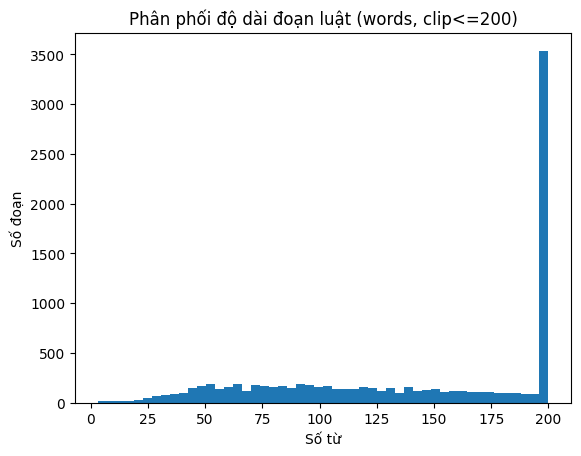

In [7]:
# Histogram độ dài đoạn
plt.figure()
plt.hist(df["n_words"].clip(upper=200), bins=50)
plt.title("Phân phối độ dài đoạn luật (words, clip<=200)")
plt.xlabel("Số từ")
plt.ylabel("Số đoạn")
plt.show()

In [8]:
# Chunk statistics
chunk_stats = {
    "num_chunks": len(df),
    "avg_words": df["n_words"].mean(),
    "median_words": df["n_words"].median(),
    "p90_words": df["n_words"].quantile(0.9),
    "max_words": df["n_words"].max(),
}

chunk_stats_df = pd.DataFrame([chunk_stats])
chunk_stats_df

,num_chunks,avg_words,median_words,p90_words,max_words
0,9443,179.694059,151.0,360.0,1253


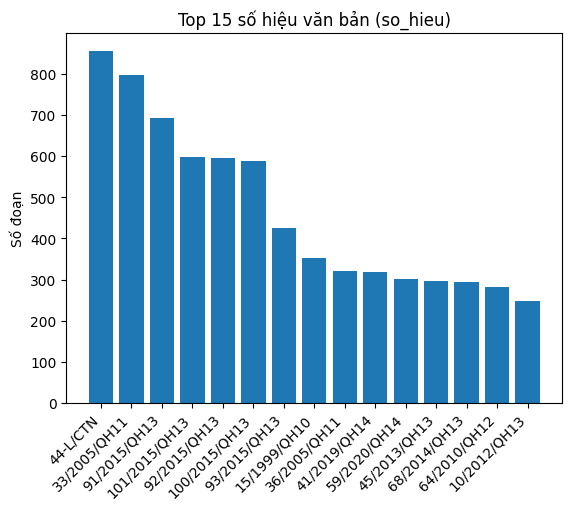

In [9]:
# Top so_hieu nếu có
if "so_hieu" in df.columns:
    top = df["so_hieu"].fillna("UNKNOWN").value_counts().head(15)
    plt.figure()
    plt.bar(top.index.astype(str), top.values)
    plt.title("Top 15 số hiệu văn bản (so_hieu)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Số đoạn")
    plt.show()
else:
    print("Không có cột so_hieu để vẽ top văn bản.")

In [10]:
# Chunking (lọc quá ngắn/quá dài), dataset gần như chunking sẵn nên phần này chỉ lọc là chính để retrieval ok hơn
MIN_WORDS = 15
MAX_WORDS = 220

before = len(df)
df = df[df["n_words"] >= MIN_WORDS].copy()

# cắt các đoạn quá dài theo số từ
def cut_words(text, max_words):
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words])

df[text_col] = df[text_col].apply(lambda t: cut_words(t, MAX_WORDS))
df["n_words"] = df[text_col].str.split().apply(len)

after = len(df)
print(f"Filtered from {before} -> {after} chunks")
df.head(2)

Filtered from 9443 -> 9390 chunks


,so_hieu,dieu,prefix,truncated_text,citation,n_words,chunk_id
0,59/2020/QH14,Điều 1,Điều 1 luật 59/2020/QH14 doanh nghiệp,Phạm vi điều chỉnh Luật này quy định về việc t...,59/2020/QH14 - Điều 1 - Điều 1 luật 59/2020/QH...,57,0
1,59/2020/QH14,Điều 2,Điều 2 luật 59/2020/QH14 doanh nghiệp,"Đối tượng áp dụng 1. Doanh nghiệp. 2. Cơ quan,...",59/2020/QH14 - Điều 2 - Điều 2 luật 59/2020/QH...,39,1


In [11]:
# Build Embeddings và FAISS
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import faiss

EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(EMB_MODEL)

texts = df[text_col].tolist()

# Encode 1 batch để lấy dim
test_vec = embedder.encode(["test"], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
dim = int(test_vec.shape[1])

index = faiss.IndexFlatIP(dim)  # cosine/IP vì normalize_embeddings=True

batch_size = 64
t0 = time.time()

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    vecs = embedder.encode(batch, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)
    vecs = vecs.astype("float32")
    index.add(vecs)

build_seconds = time.time() - t0
print("FAISS ntotal:", index.ntotal)
print("Build time (s):", round(build_seconds, 2))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|██████████| 147/147 [00:22<00:00,  6.53it/s]

FAISS ntotal: 9390
Build time (s): 22.52


In [12]:
# Retrieval latency evaluation
import time
import numpy as np

def evaluate_retrieval_latency(query, top_k=5, n_runs=100):
    latencies = []
    for _ in range(n_runs):
        t0 = time.time()
        q_vec = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
        _ = index.search(q_vec, top_k)
        t1 = time.time()
        latencies.append((t1 - t0) * 1000) # Convert to milliseconds
    return np.mean(latencies), np.std(latencies)

# Example usage
query = "Người lao động có quyền đơn phương chấm dứt hợp đồng lao động không?"
avg_lat, std_lat = evaluate_retrieval_latency(query, top_k=5, n_runs=100)
print(f"Average retrieval latency for top_k=5: {avg_lat:.2f} ms (std: {std_lat:.2f} ms)")

Average retrieval latency for top_k=5: 11.37 ms (std: 1.38 ms)


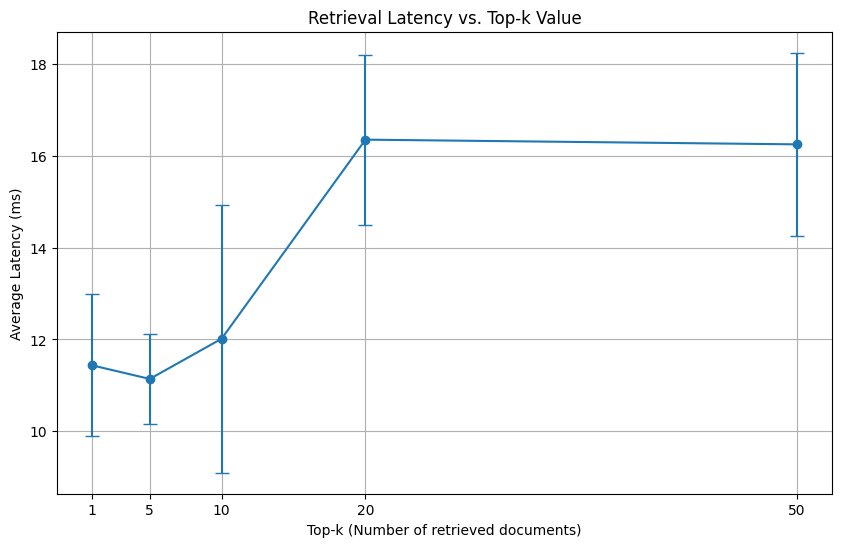

,top_k,avg_latency_ms,std_latency_ms
0,1,11.434650,1.544273
1,5,11.139174,0.986290
2,10,12.016048,2.919763
3,20,16.351585,1.850139
4,50,16.249070,1.996032


In [13]:
# BIỂU ĐỒ LATENCY
import matplotlib.pyplot as plt
import pandas as pd

query = "Người lao động có quyền đơn phương chấm dứt hợp đồng lao động không?"
top_k_values = [1, 5, 10, 20, 50]
n_runs = 50

latency_results = []
for k in top_k_values:
    avg_lat, std_lat = evaluate_retrieval_latency(query, top_k=k, n_runs=n_runs)
    latency_results.append({"top_k": k, "avg_latency_ms": avg_lat, "std_latency_ms": std_lat})

lat_df = pd.DataFrame(latency_results)

plt.figure(figsize=(10, 6))
plt.errorbar(lat_df["top_k"], lat_df["avg_latency_ms"], yerr=lat_df["std_latency_ms"], fmt='-o', capsize=5)
plt.title("Retrieval Latency vs. Top-k Value")
plt.xlabel("Top-k (Number of retrieved documents)")
plt.ylabel("Average Latency (ms)")
plt.grid(True)
plt.xticks(top_k_values)
plt.show()

display(lat_df)

In [14]:
# Lưu artifacts và zip lại để tải về demo
import pickle, json

WORK_DIR = "/content"
ART_DIR = os.path.join(WORK_DIR, "rag")
os.makedirs(ART_DIR, exist_ok=True)

faiss_path = os.path.join(ART_DIR, "faiss.index")
docstore_path = os.path.join(ART_DIR, "docstore.pkl")
config_path = os.path.join(ART_DIR, "config.json")

# save FAISS
faiss.write_index(index, faiss_path);

# docstore lưu text và citation
docstore = [
    {"text": t, "citation": c}
    for t, c in zip(df[text_col].tolist(), df["citation"].tolist())
]
with open(docstore_path, "wb") as f:
    pickle.dump(docstore, f)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump({
        "embedding_model": EMB_MODEL,
        "faiss_type": "IndexFlatIP",
        "normalize_embeddings": True,
        "min_words": MIN_WORDS,
        "max_words": MAX_WORDS,
        "num_chunks": int(len(docstore)),
        "build_seconds": float(build_seconds)
    }, f, ensure_ascii=False, indent=2)

print("Artifacts saved in:", ART_DIR)
print(os.listdir(ART_DIR))

Artifacts saved in: /content/rag
['config.json', 'docstore.pkl', 'faiss.index']


In [15]:
# Load LLM test
!pip -q install transformers accelerate torch

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLM loaded")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded


In [17]:
# Hàm test
def rag_answer_colab(query, top_k=5, max_new_tokens=256):
    # retrieve
    q_vec = embedder.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores, ids = index.search(q_vec, top_k)

    contexts = []
    citations = []
    for i in ids[0]:
        contexts.append(docstore[i]["text"])
        citations.append(docstore[i]["citation"])

    context_text = "\n".join([f"- {c}" for c in contexts])

    system_prompt = (
    "Bạn là chatbot hỗ trợ pháp luật Việt Nam. "
    "Chỉ được trả lời dựa trên nội dung pháp luật trong ngữ cảnh được cung cấp. "
    "Tuyệt đối không suy đoán hoặc bịa thông tin. "
    "Nếu ngữ cảnh không chứa thông tin liên quan đến câu hỏi, "
    "hãy trả lời: 'Chưa đủ dữ liệu pháp luật để kết luận.'"
)

    user_prompt = f"""
Câu hỏi: {query}

Ngữ cảnh pháp luật:
{context_text}

Hãy trả lời ngắn gọn, dễ hiểu và có thể viện dẫn điều luật nếu phù hợp.
"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.3,
            top_p=0.9,
            do_sample=True
        )

    # Decode only the newly generated part of the output
    answer_tokens = output[0][inputs.input_ids.shape[1]:]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
    return answer, citations

In [18]:
# Test
question = "Người lao động có quyền đơn phương chấm dứt hợp đồng lao động không?"
answer, cites = rag_answer_colab(question)

print("CÂU HỎI:")
print(question)
print("\nTRẢ LỜI:")
print(answer)

print("\nNGUỒN TRÍCH DẪN:")
for c in set(cites):
    print("-", c)

CÂU HỎI:
Người lao động có quyền đơn phương chấm dứt hợp đồng lao động không?

TRẢ LỜI:
Theo quy định của Bộ Luật Lao động 2012, người lao động có quyền đơn phương chấm dứt hợp đồng lao động trong các trường hợp cụ thể như:

1. Không được bố trí công việc, địa điểm làm việc hoặc không được bảo đảm điều kiện làm việc đã thỏa thuận trong hợp đồng lao động.

2. Không được trả lương đầy đủ hoặc trả lương không đúng thời hạn đã thỏa thuận trong hợp đồng lao động.

3. Bị ngược đãi, quấy rối tình dục, cưỡng bức lao động.

4. Bản thân hoặc gia đình có hoàn cảnh khó khăn không thể tiếp tục thực hiện hợp đồng lao động.

5. Được bầu làm nhiệm vụ chuyên trách ở cơ quan dân cử hoặc được bổ nhiệm giữ chức vụ trong bộ máy nhà nước.

6. Lao động nữ mang thai phải nghỉ việc theo chỉ định của cơ sở khám bệnh, chữa bệnh có thẩm quyền.

7. Người lao động bị ốm đau, tai nạn đã điều trị 90 ngày liên tục đối với người làm việc.

Tuy nhiên, người lao động không có quyền đơn phương chấm dứt hợp đồng lao động k

In [19]:

# RAG System Summary
print("CHATBOT LUẬT VIỆT NAM")
print(f"Số chunk: {len(df)}")
print(f"Embedding model: {EMB_MODEL}")
print(f"FAISS index type: IndexFlatIP (cosine)")
print(f"Thời gian build index (s): {round(build_seconds, 2)}")
print(f"Top-k retrieval: 5")
print("LLM: Transformer pretrained (Qwen)")
print("Tri thức xây dựng offline, sinh câu trả lời khi demo")

CHATBOT LUẬT VIỆT NAM
Số chunk: 9390
Embedding model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
FAISS index type: IndexFlatIP (cosine)
Thời gian build index (s): 22.52
Top-k retrieval: 5
LLM: Transformer pretrained (Qwen)
Tri thức xây dựng offline, sinh câu trả lời khi demo


In [20]:
# Nén và tải artifacts
import shutil
from google.colab import files

RAG_DIR = "rag"
ZIP_NAME = "artifacts.zip"

# Nén thư mục rag
shutil.make_archive(
    base_name=ZIP_NAME.replace(".zip", ""),
    format="zip",
    root_dir=RAG_DIR
)

print(f"Đã nén xong: {ZIP_NAME}")

# Tải về
files.download(ZIP_NAME)

Đã nén xong: artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>